## Step 1 - Import Libraries


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2 - Load Dataset


In [44]:
df = pd.read_csv('data.csv')
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Step 3 - Explore Data


In [45]:
print(df.info())
print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

## Step 4 - Imputation


### Check Missing Values Before Imputation

In [46]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [47]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].mean())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mean())
df['Market Category'] = df['Market Category'].fillna('Unknown')
print(df['Engine HP'])
print(df['Engine Cylinders'])
print(df['Market Category'])


0        335.0
1        300.0
2        300.0
3        230.0
4        230.0
         ...  
11909    300.0
11910    300.0
11911    300.0
11912    300.0
11913    221.0
Name: Engine HP, Length: 11914, dtype: float64
0        6.0
1        6.0
2        6.0
3        6.0
4        6.0
        ... 
11909    6.0
11910    6.0
11911    6.0
11912    6.0
11913    6.0
Name: Engine Cylinders, Length: 11914, dtype: float64
0        Factory Tuner,Luxury,High-Performance
1                           Luxury,Performance
2                      Luxury,High-Performance
3                           Luxury,Performance
4                                       Luxury
                         ...                  
11909               Crossover,Hatchback,Luxury
11910               Crossover,Hatchback,Luxury
11911               Crossover,Hatchback,Luxury
11912               Crossover,Hatchback,Luxury
11913                                   Luxury
Name: Market Category, Length: 11914, dtype: str


## Step 5 - Removal


In [48]:
df = df.dropna(subset = ['Number of Doors','Engine Fuel Type'])
df.isna().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

## Step 6 - Check Duplicates


In [49]:
print(df.duplicated().sum())


715


## Step 7 - Remove Duplicates


In [50]:
df = df.drop_duplicates()
print(df.duplicated().sum())


0


## Step 8 - Data Type Conversion


In [51]:
df['Year'] = df['Year'].astype(int)
print(df['Year'].dtypes)

int64


## Step 9 - Top Brands Bar Chart


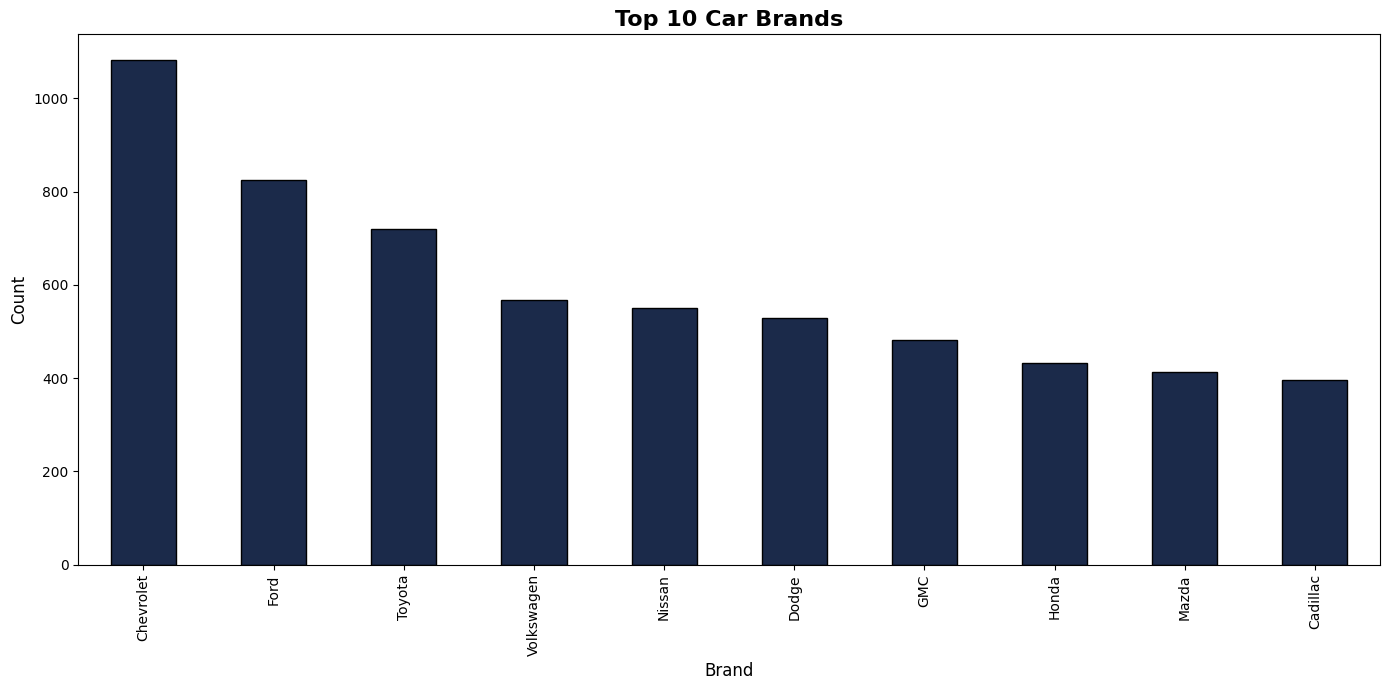

In [52]:
plt.figure(figsize=(14,7))
brand_counts = df.groupby('Make').size().sort_values(ascending=False).head(10)
brand_counts.plot(kind='bar',color='#1B2A4A',edgecolor='black')
plt.title('Top 10 Car Brands',fontsize=16, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


## Step 10 - Avg Price by Brand


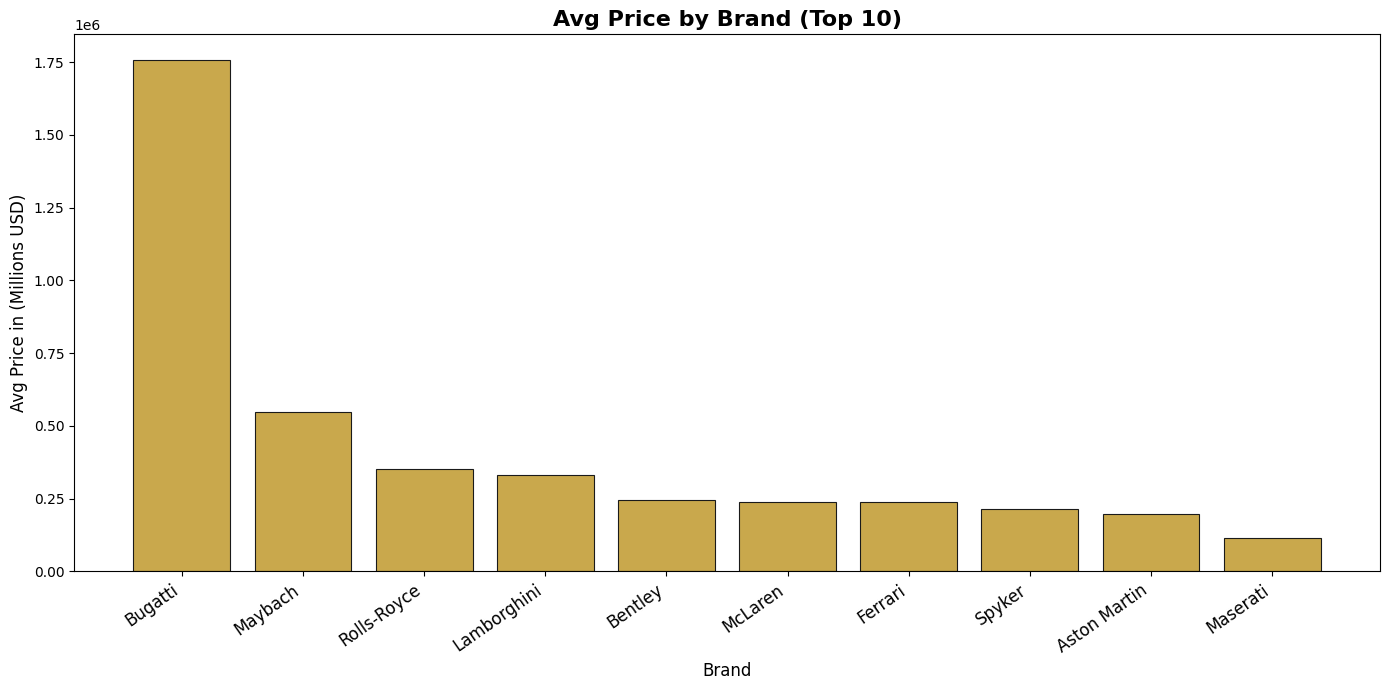

In [53]:
plt.figure(figsize=(14,7))
avg_price = df.groupby('Make')['MSRP'].mean().sort_values(ascending=False).head(10)
bars = plt.bar(avg_price.index, avg_price.values,color='#C9A84C', edgecolor='#1a1a1a', linewidth=0.8)
plt.title('Avg Price by Brand (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Avg Price in (Millions USD)', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=12) 
plt.tight_layout()
plt.show()


## Step 11 - Avg Price Over Years (Line Chart)


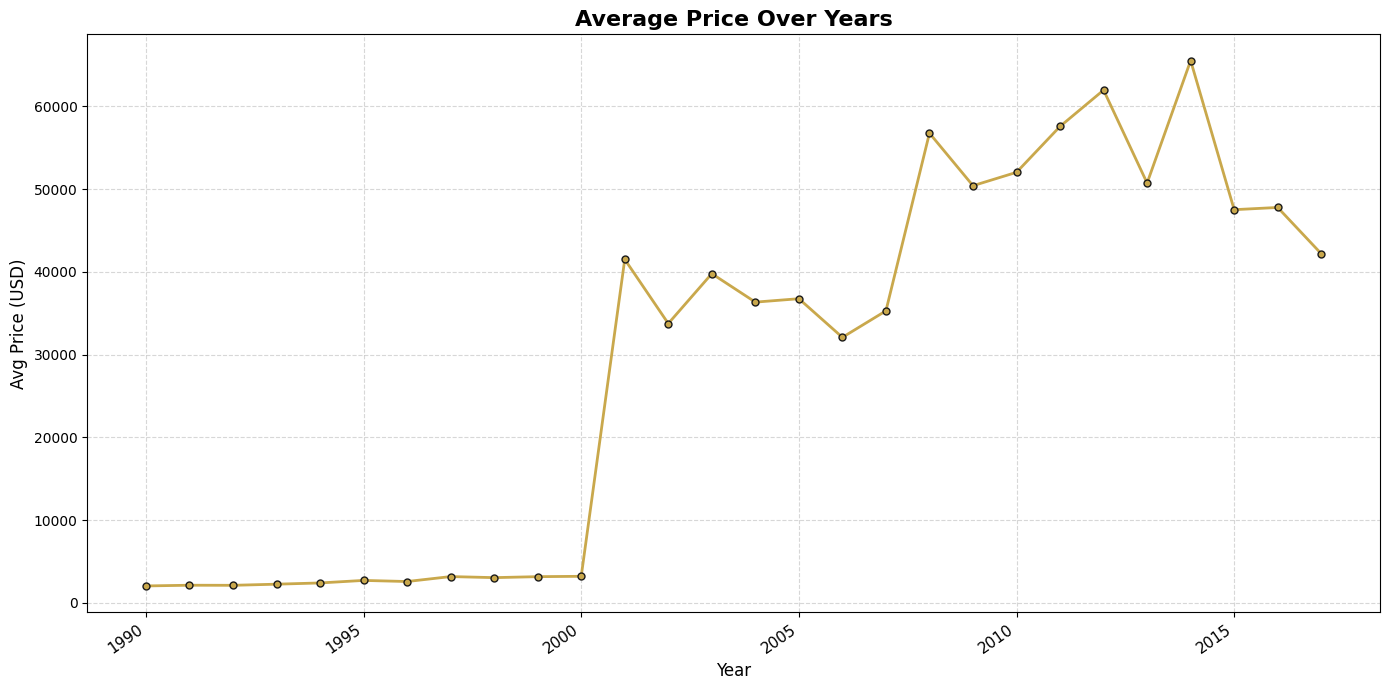

In [54]:
line_data = df.groupby('Year')['MSRP'].mean()
plt.figure(figsize=(14, 7))
plt.plot(line_data.index, line_data.values, color='#C9A84C', linewidth=2, marker='o', markersize=5, markeredgecolor='#1a1a1a')
plt.title('Average Price Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Avg Price (USD)', fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Step 12 - Avg MSRP by Engine Cylinders (Scatter)


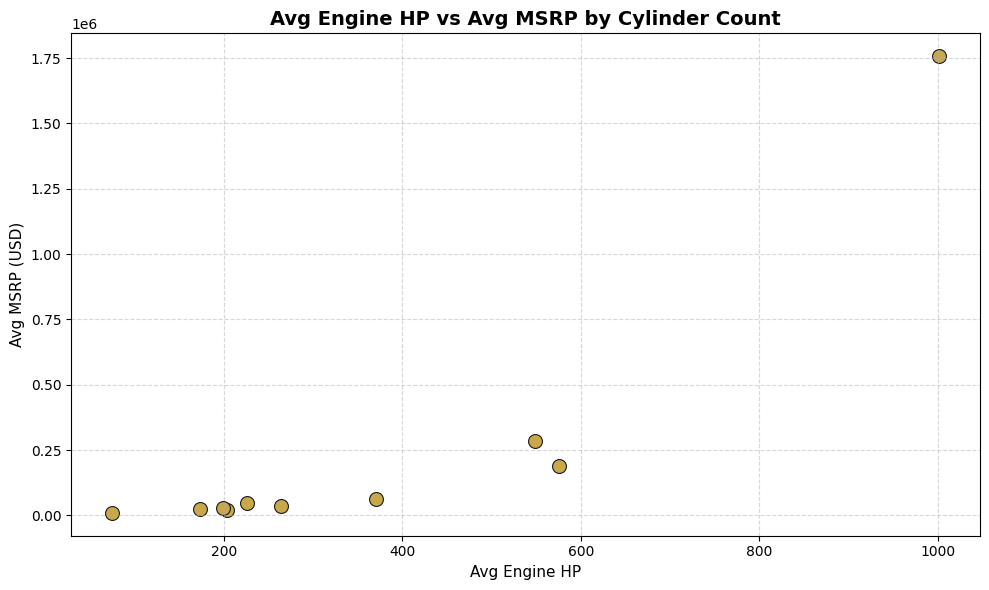

In [55]:
scatter_data = df.groupby('Engine Cylinders').agg(
    avg_hp=('Engine HP', 'mean'),
    avg_msrp=('MSRP', 'mean'),
    count=('MSRP', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_data['avg_hp'],
    scatter_data['avg_msrp'],
    s=100,
    color='#C9A84C',
    edgecolors='#1a1a1a',
    linewidths=0.8
)

plt.title('Avg Engine HP vs Avg MSRP by Cylinder Count', fontsize=14, fontweight='bold')
plt.xlabel('Avg Engine HP', fontsize=11)
plt.ylabel('Avg MSRP (USD)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Step 13 - Fuel Type Distribution (Pie Chart)


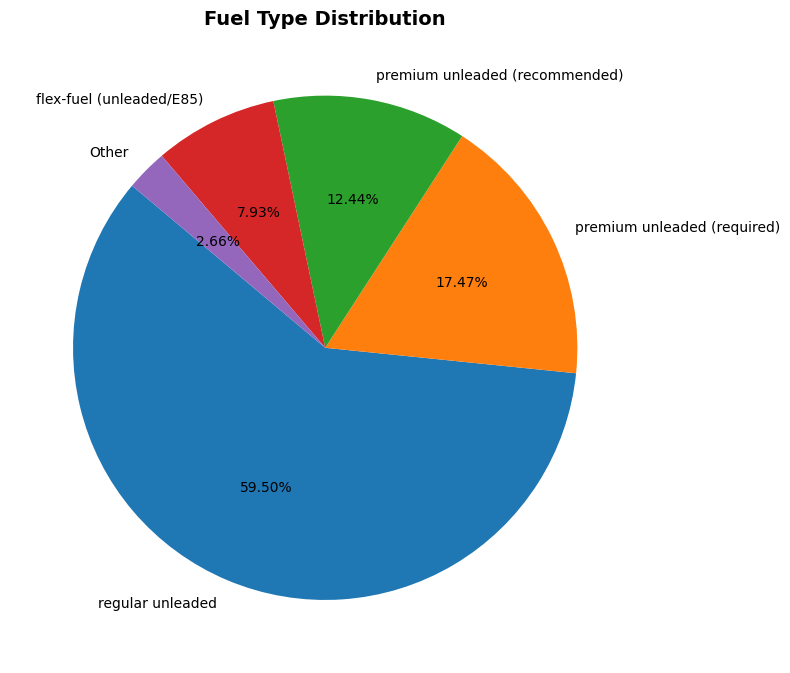

In [56]:
fuel_counts = df['Engine Fuel Type'].value_counts()

threshold = fuel_counts.sum() * 0.02
main = fuel_counts[fuel_counts >= threshold]
other = fuel_counts[fuel_counts < threshold].sum()
if other > 0:
    import pandas as pd
    main = pd.concat([main, pd.Series({'Other': other})])

plt.figure(figsize=(8, 8))
plt.pie(
    main,
    labels=main.index,
    autopct='%.2f%%',
    startangle=140
)
plt.title('Fuel Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 14 - Histogram


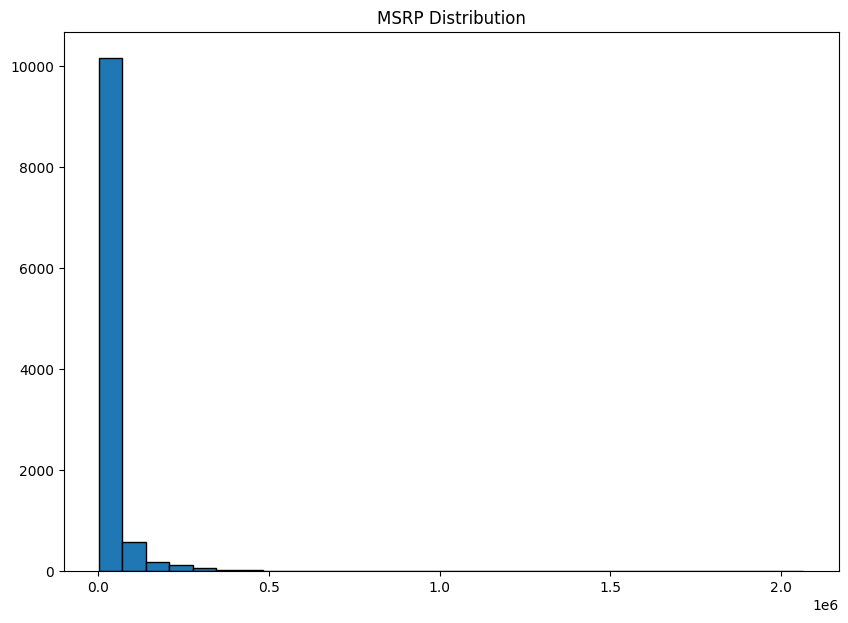

In [57]:
plt.figure(figsize=(10,7))
plt.hist(df['MSRP'], bins=30, edgecolor='black')
plt.title('MSRP Distribution')
plt.show()


## Step 15 - Correlation Heatmap


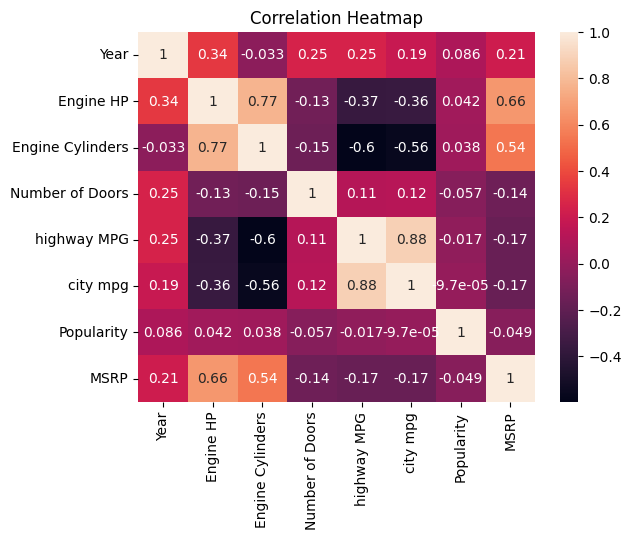

In [58]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()


## Step 16 - Filtering


In [59]:
filtered = df[df['MSRP'] > 50000]
filtered.head()



,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
49,BMW,2 Series,2016,premium unleaded (required),320.0,6.0,AUTOMATIC,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Convertible,30,20,3916,50750
52,BMW,2 Series,2017,premium unleaded (recommended),335.0,6.0,AUTOMATIC,all wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Convertible,32,21,3916,51050
132,BMW,3 Series,2015,premium unleaded (required),335.0,6.0,AUTOMATIC,rear wheel drive,4.0,"Luxury,High-Performance,Hybrid",Midsize,Sedan,33,25,3916,50150
294,Ferrari,360,2002,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,15,10,2774,160829
295,Ferrari,360,2002,premium unleaded (required),400.0,8.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,15,10,2774,140615


## Step 18 - Export CSV


In [42]:
df.reset_index(drop=True, inplace=True)
df.to_csv('cleaned_car_data.csv', index=False)
print('CSV exported successfully!')


CSV exported successfully!
